# 数据探查：快讯 (flash)

路径：`/home/intern_fjq_2026/data/NLP/news/flash_20240101_20241231.jsonl`

目标：彻底理解这份新闻类 jsonl 的整体数据结构。

> 前 3 个逻辑 cell：`read_json` 加载 `df` → `df.head()` → 打印 `shape` 与 `columns`。
> 注意：该文件只有 **标题 + 摘要**，完整正文经 `S3_URL` 指向的对象存储读取，不在本 jsonl 内。


In [1]:
import pandas as pd

df = pd.read_json('/home/intern_fjq_2026/data/NLP/news/flash_20240101_20241231.jsonl', lines=True)


In [2]:
df.head()


,NEWS_ID,NEWS_TITLE,NEWS_PUBLISH_TIME,EFFECTIVE_TIME,NEWS_ORIGIN_SOURCE,NEWS_AUTHOR,NEWS_PUBLISH_SITE,NEWS_URL,S3_URL,NEWS_SUMMARY
0,160468592,【2024 新年快乐】辞旧迎新，财源广进。金十数据祝各位交易者新的一年交易顺利，红红火火，财...,2024-01-01 00:00:00,2024-01-01 00:02:18,None,None,金十数据,https://flash.jin10.com/detail/202401010000000...,/newsbody/RRGTxKL3XqViPssekvc4bA,金十数据祝各位交易者新的一年交易顺利，红红火火，财富滚滚来。
1,160468602,2024年格隆汇“全球视野，下注中国”十大核心资产名单重磅揭晓！,2024-01-01 00:01:24,2024-01-01 00:02:38,None,None,格隆汇,https://www.gelonghui.com/live/1355566,/newsbody/gemapEUqsKBonpzbHjNn1A,不同于往年以“年度”为时间跨度进行调整，格隆汇2024年“十大核心资产”将进行“季度调整”。...
2,160468604,2024超级选举年——俄罗斯(3月15至17日),2024-01-01 00:00:40,2024-01-01 00:02:38,None,None,格隆汇,https://www.gelonghui.com/live/1355563,/newsbody/dkG7-AwfGR8d8hsJAqGTRA,格隆汇12月31日|2024年将有人口总数达42亿的国家或地区进行关键选举。俄罗斯2024年...
3,160468605,2024年格隆汇“全球视野 下注中国”十大核心ETF重磅揭晓！,2024-01-01 00:01:03,2024-01-01 00:02:38,None,None,格隆汇,https://www.gelonghui.com/live/1355564,/newsbody/imIVJ46RR_BZraDAdTt9jw,2024年格隆汇“全球视野 下注中国”十大核心ETF重磅揭晓！
4,160468616,财联社愿您在2024年财运亨通、事业蒸蒸日上,2024-01-01 00:00:27,2024-01-01 00:03:23,None,None,财联社,https://api3.cls.cn/share/article/1558925,/newsbody/94Ka9OxrL_awzK2RVn-hUg,值此新年之际，财联社全体同仁向您致以最诚挚的祝福。在挑战与机遇并存的一年中，财联社坚守专业使...


In [3]:
print("shape:", df.shape)
print("columns:")
print(df.columns.tolist())


shape: (1487456, 10)
columns:
['NEWS_ID', 'NEWS_TITLE', 'NEWS_PUBLISH_TIME', 'EFFECTIVE_TIME', 'NEWS_ORIGIN_SOURCE', 'NEWS_AUTHOR', 'NEWS_PUBLISH_SITE', 'NEWS_URL', 'S3_URL', 'NEWS_SUMMARY']


In [4]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["font.sans-serif"] = ["WenQuanYi Micro Hei", "WenQuanYi Zen Hei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("DataFrame shape:", df.shape)
print("内存占用(deep): {:.1f} MB".format(df.memory_usage(deep=True).sum() / 1024**2))
time_cols = ["NEWS_PUBLISH_TIME", "EFFECTIVE_TIME"]
text_cols = ["NEWS_TITLE", "NEWS_SUMMARY"]
cat_cols  = ["NEWS_ORIGIN_SOURCE", "NEWS_AUTHOR", "NEWS_PUBLISH_SITE"]
url_cols  = ["NEWS_URL", "S3_URL"]
id_cols   = ["NEWS_ID"]

field_meaning = {
    "NEWS_ID": "新闻唯一ID",
    "NEWS_TITLE": "新闻标题",
    "NEWS_PUBLISH_TIME": "发布时间",
    "EFFECTIVE_TIME": "生效/抓取时间",
    "NEWS_ORIGIN_SOURCE": "原始来源媒体",
    "NEWS_AUTHOR": "作者",
    "NEWS_PUBLISH_SITE": "发布站点",
    "NEWS_URL": "原文链接",
    "S3_URL": "正文存储路径(S3 key)",
    "NEWS_SUMMARY": "新闻摘要",
}
pd.DataFrame({"字段含义": field_meaning}).reindex(df.columns)


DataFrame shape: (1487456, 10)


内存占用(deep): 1065.0 MB


,字段含义
NEWS_ID,新闻唯一ID
NEWS_TITLE,新闻标题
NEWS_PUBLISH_TIME,发布时间
EFFECTIVE_TIME,生效/抓取时间
NEWS_ORIGIN_SOURCE,原始来源媒体
NEWS_AUTHOR,作者
NEWS_PUBLISH_SITE,发布站点
NEWS_URL,原文链接
S3_URL,正文存储路径(S3 key)
NEWS_SUMMARY,新闻摘要


## 1. 字段类型 / 缺失 / 唯一值总览


In [5]:
# ============================================================
# 1. 字段类型 / 缺失 / 唯一值总览
# ============================================================
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "null": df.isna().sum(),
    "null_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=False),
})
overview.sort_values(["null_pct", "n_unique"], ascending=[False, False])


,dtype,non_null,null,null_pct,n_unique
NEWS_AUTHOR,object,231677,1255779,84.42,29
NEWS_ORIGIN_SOURCE,object,302873,1184583,79.64,146
NEWS_SUMMARY,object,1486652,804,0.05,915598
S3_URL,object,1487269,187,0.01,1487270
NEWS_ID,int64,1487456,0,0.00,1487456
NEWS_URL,object,1487456,0,0.00,1487456
NEWS_PUBLISH_TIME,datetime64[ns],1487456,0,0.00,1284612
NEWS_TITLE,object,1487456,0,0.00,861545
EFFECTIVE_TIME,datetime64[ns],1487456,0,0.00,622024
NEWS_PUBLISH_SITE,object,1487456,0,0.00,13


## 2. 主键 / 唯一性 / 重复


In [6]:
# ============================================================
# 2. 主键 / 唯一性 / 重复
# ============================================================
print("总行数:", len(df))
print("NEWS_ID 唯一性 is_unique =", df["NEWS_ID"].is_unique, "| 唯一值数 =", df["NEWS_ID"].nunique())
print("完全重复的行数 =", int(df.duplicated().sum()))
print("去掉 NEWS_ID 后仍完全重复的记录数 =", int(df.drop(columns=["NEWS_ID"]).duplicated().sum()))
print("S3_URL 非空 = %d，唯一值 = %d，重复(正文指针复用) = %d" % (
    int(df["S3_URL"].notna().sum()), df["S3_URL"].nunique(),
    int(df["S3_URL"].dropna().duplicated().sum())))


总行数: 1487456
NEWS_ID 唯一性 is_unique = True | 唯一值数 = 1487456


完全重复的行数 = 0


去掉 NEWS_ID 后仍完全重复的记录数 = 0


S3_URL 非空 = 1487269，唯一值 = 1487269，重复(正文指针复用) = 0


## 3. 时间维度


NEWS_PUBLISH_TIME 解析失败行数: 0
发布时间范围: 2023-12-31 23:55:38 → 2024-12-31 23:58:19
发布时间去重日期数: 367

按月发布量：
2023-12         1
2024-01    122428
2024-02    100523
2024-03    125995
2024-04    138450
2024-05    127043
2024-06    122153
2024-07    140861
2024-08    134666
2024-09    119725
2024-10    129284
2024-11    116373
2024-12    109954
Freq: M, Name: NEWS_PUBLISH_TIME, dtype: int64

生效时间 - 发布时间 时差(分钟): min/中位/均值/max = -45.2 / 2.6 / 3.4 / 718.4


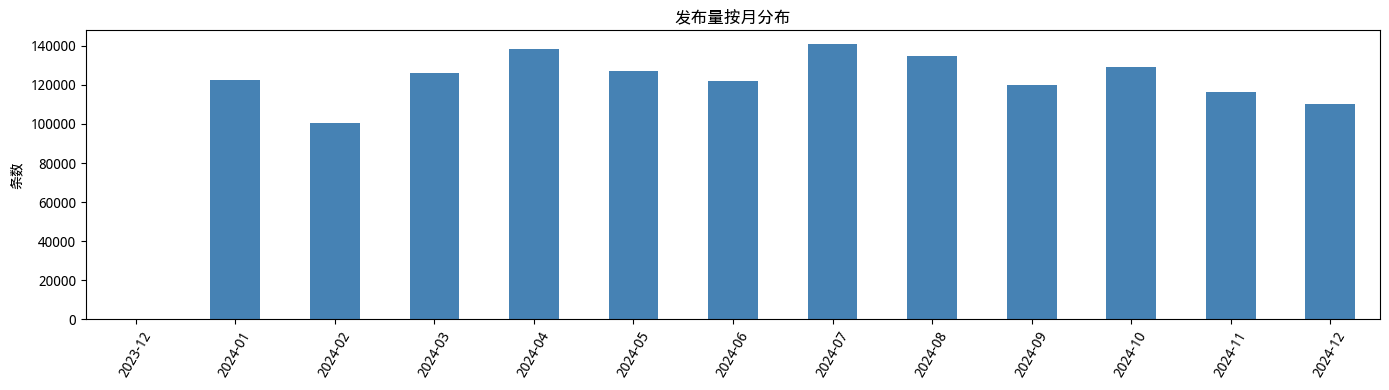

In [7]:
# ============================================================
# 3. 时间维度
# ============================================================
pub = pd.to_datetime(df["NEWS_PUBLISH_TIME"], errors="coerce")
eff = pd.to_datetime(df["EFFECTIVE_TIME"], errors="coerce")
print("NEWS_PUBLISH_TIME 解析失败行数:", int(pub.isna().sum()))
print("发布时间范围:", pub.min(), "→", pub.max())
print("发布时间去重日期数:", pub.dt.normalize().nunique())

monthly = pub.dt.to_period("M").value_counts().sort_index()
print("\n按月发布量：")
print(monthly)

lag_min = (eff - pub).dt.total_seconds() / 60
print("\n生效时间 - 发布时间 时差(分钟): min/中位/均值/max = %.1f / %.1f / %.1f / %.1f" % (
    lag_min.min(), lag_min.median(), lag_min.mean(), lag_min.max()))

plt.figure(figsize=(14, 4))
monthly.plot(kind="bar", color="steelblue")
plt.title("发布量按月分布")
plt.ylabel("条数")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


## 4. 文本字段（TITLE / SUMMARY）


NEWS_TITLE 无缺失 = True | 长度 min/中位/均值/max = 3 / 27.0 / 37.7 / 300

NEWS_SUMMARY 非空 1486652 / 1487456，缺失 804 (0.05%)


NEWS_SUMMARY(非空) 长度：min/中位/均值/max = 4 / 63.0 / 64.2 / 300
SUMMARY 长度分位数：
0.00      4.0
0.25     36.0
0.50     63.0
0.75     90.0
0.90    108.0
0.99    119.0
1.00    300.0
Name: NEWS_SUMMARY, dtype: float64



标题去重: TITLE 唯一值 861545 / 行数 1487456，重复标题行数 = 625911


摘要去重: SUMMARY 唯一值(非空) 915597 / 非空 1486652，重复摘要条数 = 571055


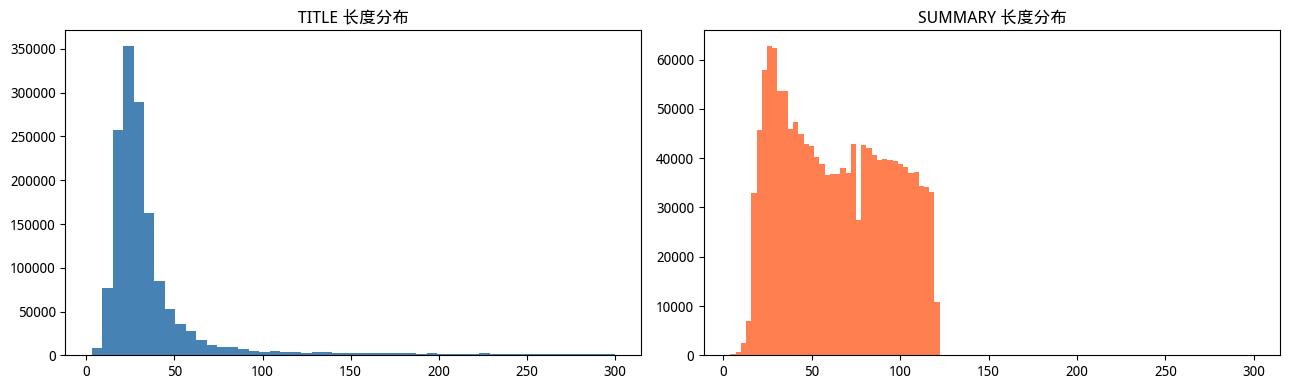


--- 最长摘要样本 ---
index=1051000, 长度=300, 标题=【中信证券：债市波动下8月规模仍增3000亿元 9月季节性下降无需担忧】9月11日讯，中信证券研报表示，2024年8月债市波动期间，信用债一度连续回调引发市场担忧赎回风波再起，但据我们测算，理财规模8月仍大幅增长3000亿元至30.6万亿元，增幅也超过2018—2023年的均值2600亿元，表明债市波动并未大规模传导至理财负债端，从破净率来看，据我们测算，最高点是8月底的2.83%，9月10日已经恢复至2.38%，远不及去年中4.25%的高点，更遑论2022年底25%的历史极值，后续来看，我们预计9月理财规模可能季节性回撤6000亿元左右，但10月将很快修复并续创新高，仍将为债市带来有力支撑。
【中信证券：债市波动下8月规模仍增3000亿元 9月季节性下降无需担忧】9月11日讯，中信证券研报表示，2024年8月债市波动期间，信用债一度连续回调引发市场担忧赎回风波再起，但据我们测算，理财规模8月仍大幅增长3000亿元至30.6万亿元，增幅也超过2018—2023年的均值2600亿元，表明债市波动并未大规模传导至理财负债端，从破净率来看，据我们测算，最高点是8月底的2.83%，9月10日已经恢复至2.38%，远不及去年中4.25%的高点，更遑论2022年底25%的历史极值，后续来看，我们预计9月理财规模可能季节性回撤6000亿元左右，但10月将很快修复并续创新高，仍将为债市带来有力支撑。

--- 最短摘要样本 ---
index=268389, 长度=4, 标题=道指转跌
'道指转跌'


In [8]:
# ============================================================
# 4. 文本字段长度 / 重复 / 样本
# ============================================================
title_len = df["NEWS_TITLE"].str.len()
print("NEWS_TITLE 无缺失 =", bool(df["NEWS_TITLE"].notna().all()),
      "| 长度 min/中位/均值/max = %d / %.1f / %.1f / %d" % (
          title_len.min(), title_len.median(), title_len.mean(), title_len.max()))

summary = df["NEWS_SUMMARY"].dropna()
print("\nNEWS_SUMMARY 非空 %d / %d，缺失 %d (%.2f%%)" % (
    len(summary), len(df),
    int(df["NEWS_SUMMARY"].isna().sum()), df["NEWS_SUMMARY"].isna().mean() * 100))
slen = summary.str.len()
print("NEWS_SUMMARY(非空) 长度：min/中位/均值/max = %d / %.1f / %.1f / %d" % (
    slen.min(), slen.median(), slen.mean(), slen.max()))
print("SUMMARY 长度分位数：")
print(slen.quantile([0.0, 0.25, 0.5, 0.75, 0.9, 0.99, 1.0]))

print("\n标题去重: TITLE 唯一值 %d / 行数 %d，重复标题行数 = %d" % (
    df["NEWS_TITLE"].nunique(), len(df), int(df["NEWS_TITLE"].duplicated().sum())))
print("摘要去重: SUMMARY 唯一值(非空) %d / 非空 %d，重复摘要条数 = %d" % (
    summary.nunique(), len(summary), int(summary.duplicated().sum())))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(title_len, bins=50, color="steelblue")
axes[0].set_title("TITLE 长度分布")
axes[1].hist(slen, bins=100, color="coral")
axes[1].set_title("SUMMARY 长度分布")
plt.tight_layout()
plt.show()

print("\n--- 最长摘要样本 ---")
i = slen.idxmax()
print("index=%d, 长度=%d, 标题=%s" % (i, slen[i], df.loc[i, "NEWS_TITLE"]))
print(df.loc[i, "NEWS_SUMMARY"][:1500])
print("\n--- 最短摘要样本 ---")
j = slen.idxmin()
print("index=%d, 长度=%d, 标题=%s" % (j, slen[j], df.loc[j, "NEWS_TITLE"]))
print(repr(df.loc[j, "NEWS_SUMMARY"]))


## 5. 分类字段（来源媒体 / 作者 / 站点）


NEWS_ORIGIN_SOURCE  唯一值数=145
None         1184583
财联社           135292
同花顺7x24快讯     132155
界面新闻           23787
中国证券报·中证网       9748
中证金牛座            935
同花顺金融研究中心        220
腾讯自选股            174
央视新闻             106
新华社               84
同花顺               24
中国网               21
证监会               20
证券时报              13
第一财经              13
美港电讯              13
澎湃新闻              10
界面                 8
21世纪经济报道           8
发改委                8

NEWS_AUTHOR  唯一值数=28


None         1255779
7X24快讯        108528
罗俊             26262
万小婷            23423
田晓艳            16849
葛冬瑾            16561
姜超             14281
石惠              7527
数据团队            5953
龙玥              5728
A股团队            3305
bumblebee       2303
贺晨               332
袁佳颖              328
田铁军              137
债券团队              42
许超                32
陈晨                17
房家瑶               16
朱希                12



NEWS_PUBLISH_SITE  唯一值数=13


金十数据     286940
汇通网      176612
格隆汇      166383
财联社      151549
腾讯自选股    136012
同花顺      132391
华尔街见闻    124663
雪球       108528
21经济网     88181
选股宝       70498
界面        33751
中证网       10691
投中网        1257



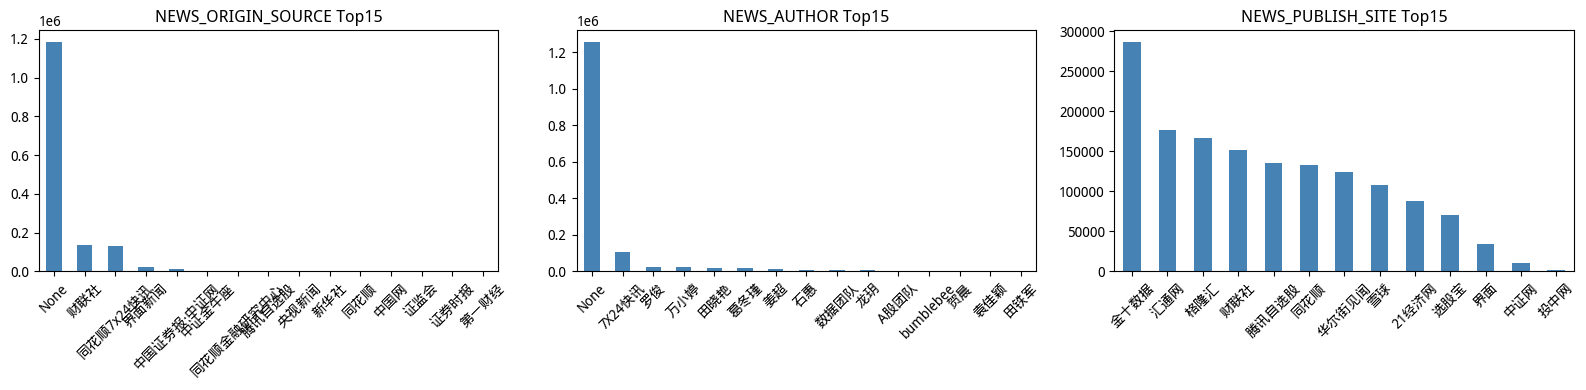

In [9]:
# ============================================================
# 5. 分类字段取值分布
# ============================================================
for c in cat_cols:
    print("=" * 70)
    print("%s  唯一值数=%d" % (c, df[c].nunique(dropna=True)))
    print(df[c].value_counts(dropna=False).head(20).to_string())
    print()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, c in enumerate(cat_cols):
    df[c].value_counts(dropna=False).head(15).plot(kind="bar", ax=axes[i], color="steelblue")
    axes[i].set_title(c + " Top15")
    axes[i].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## 6. 链接与正文存储指针


In [10]:
# ============================================================
# 6. 链接与正文存储指针
# ============================================================
dom = df["NEWS_URL"].dropna().str.extract(r"https?://([^/]+)", expand=False)
print("NEWS_URL 域名 Top20：")
print(dom.value_counts().head(20).to_string())

print("\nS3_URL 前缀样例(前 10)：")
for s in df["S3_URL"].dropna().unique()[:10]:
    print("  ", s)
print("S3_URL 去重唯一值 =", df["S3_URL"].nunique(),
      "| 复用 (重复) 的指针数 =", int(df["S3_URL"].dropna().duplicated().sum()))


NEWS_URL 域名 Top20：
flash.jin10.com            286940
www.fx678.com              176612
www.gelonghui.com          166383
gu.qq.com                  136012
news.10jqka.com.cn         132391
api3.cls.cn                125757
wallstreetcn.com           124663
xueqiu.com                 108528
m.21jingji.com              88181
xuangubao.cn                70498
www.jiemian.com             33751
www.cls.cn                  25792
www.cs.com.cn               10689
www.chinaventure.com.cn      1257
jnzstatic.cs.com.cn             2

S3_URL 前缀样例(前 10)：


   /newsbody/RRGTxKL3XqViPssekvc4bA
   /newsbody/gemapEUqsKBonpzbHjNn1A
   /newsbody/dkG7-AwfGR8d8hsJAqGTRA
   /newsbody/imIVJ46RR_BZraDAdTt9jw
   /newsbody/94Ka9OxrL_awzK2RVn-hUg
   /newsbody/2ABP4exyK09X3l7PVivykg
   /newsbody/qSTHg5TyasL6-AYaW5Scjw
   /newsbody/YvjhM4kyQTsodU4Hcidx1Q
   /newsbody/jy60cvvGkR1MQrDkYTWjuA
   /newsbody/2VTNAZfm61aiiM4Dv8FoSg


S3_URL 去重唯一值 = 1487269 | 复用 (重复) 的指针数 = 0


## 7. 来源媒体 ↔ 站点 / 作者 关系


In [11]:
# ============================================================
# 7. 来源媒体 ↔ 站点 / 作者 关系
# ============================================================
src_sites = df.groupby("NEWS_ORIGIN_SOURCE")["NEWS_PUBLISH_SITE"].nunique().sort_values(ascending=False)
print("每个来源媒体对应发布站点数 Top20：")
print(src_sites.head(20).to_string())

site_authors = df.groupby("NEWS_PUBLISH_SITE")["NEWS_AUTHOR"].nunique().sort_values(ascending=False)
print("\n每个站点作者数 Top20：")
print(site_authors.head(20).to_string())


每个来源媒体对应发布站点数 Top20：
NEWS_ORIGIN_SOURCE
新华社           3
21世纪经济报道      2
证监会网站         2
国资委网站         2
每日经济新闻        2
界面新闻          2
中国证券网         2
中国证券报·中证网     2
中国人民银行网站      2
证券日报          2
证券时报网         2
中证金牛座         2
贝壳财经          1
恒信东方公众号       1
深交所互动易        1
深交所           1
每经网           1
金融监管总局        1
晚点LatePost    1
晚点AUTO        1



每个站点作者数 Top20：
NEWS_PUBLISH_SITE
华尔街见闻    27
雪球        1
21经济网     0
中证网       0
同花顺       0
投中网       0
格隆汇       0
汇通网       0
界面        0
腾讯自选股     0
财联社       0
选股宝       0
金十数据      0


## 8. 原始数据抽样查看


In [12]:
# ============================================================
# 8. 原始数据抽样查看
# ============================================================
sample = df.sample(n=3, random_state=42)
for i, (idx, row) in enumerate(sample.iterrows(), 1):
    print("=" * 80)
    print("样本 %d / 3   (原始 index=%d, NEWS_ID=%s)" % (i, idx, row["NEWS_ID"]))
    print("-" * 80)
    for col in df.columns:
        val = row[col]
        if isinstance(val, str) and len(val) > 300:
            val = val[:300] + "  ......[截断]"
        print("%-22s : %s" % (col, val))
    print()


样本 1 / 3   (原始 index=903284, NEWS_ID=179484105)
--------------------------------------------------------------------------------
NEWS_ID                : 179484105
NEWS_TITLE             : 【摩根大通美国国债客户多头占比升至年内新高】8月6日讯，摩根大通美国国债客户调查显示，截至8月5日当周，多头占比上升4个百分点，至去年12月11日以来的最高水平，中性占比下降，空头占比持平。净多头头寸为3月25日以来最高。
NEWS_PUBLISH_TIME      : 2024-08-06 19:41:52
EFFECTIVE_TIME         : 2024-08-06 19:48:03
NEWS_ORIGIN_SOURCE     : None
NEWS_AUTHOR            : None
NEWS_PUBLISH_SITE      : 汇通网
NEWS_URL               : https://www.fx678.com/C/20240806/202408061941521053.html
S3_URL                 : /newsbody/SSacFvieMma36cB_7T_uVA
NEWS_SUMMARY           : 截至8月5日当周，多头占比上升4个百分点，至去年12月11日以来的最高水平，中性占比下降，空头占比持平。净多头头寸为3月25日以来最高。

样本 2 / 3   (原始 index=792998, NEWS_ID=177070571)
--------------------------------------------------------------------------------
NEWS_ID                : 177070571
NEWS_TITLE             : 新冠疫苗7月15日起不再免费接种？多家医院回应
NEWS_PUBLISH_TIME      : 2024-07-12 14:26:12
EFFECTIVE_TIME         : 20

## 9. 结论摘要（自动汇总）


In [13]:
# ============================================================
# 9. 结论摘要（自动汇总）
# ============================================================
pub_dt = pd.to_datetime(df["NEWS_PUBLISH_TIME"], errors="coerce")
lines = []
lines.append("文件: /home/intern_fjq_2026/data/NLP/news/flash_20240101_20241231.jsonl")
lines.append("总记录数: %d 行 × %d 列" % df.shape)
lines.append("发布时间范围: %s ~ %s (去重日期 %d 天)" % (
    pub_dt.min(), pub_dt.max(), pub_dt.dt.normalize().nunique()))
lines.append("NEWS_ID 唯一: %s；完全重复行: %d；去掉 ID 后重复: %d" % (
    df["NEWS_ID"].is_unique, int(df.duplicated().sum()),
    int(df.drop(columns=["NEWS_ID"]).duplicated().sum())))
lines.append("发布站点 %d 个 / 来源媒体 %d 个 / 作者 %d 个" % (
    df["NEWS_PUBLISH_SITE"].nunique(), df["NEWS_ORIGIN_SOURCE"].nunique(),
    df["NEWS_AUTHOR"].nunique()))
lines.append("摘要(NEWS_SUMMARY)缺失率: %.2f%%；标题缺失率: %.2f%%；标题重复数: %d" % (
    df["NEWS_SUMMARY"].isna().mean()*100, df["NEWS_TITLE"].isna().mean()*100,
    int(df["NEWS_TITLE"].duplicated().sum())))
lines.append("S3_URL(正文指针) 非空 %d，唯一 %d，复用 %d" % (
    int(df["S3_URL"].notna().sum()), df["S3_URL"].nunique(),
    int(df["S3_URL"].dropna().duplicated().sum())))
print("\n".join(lines))


文件: /home/intern_fjq_2026/data/NLP/news/flash_20240101_20241231.jsonl
总记录数: 1487456 行 × 10 列
发布时间范围: 2023-12-31 23:55:38 ~ 2024-12-31 23:58:19 (去重日期 367 天)
NEWS_ID 唯一: True；完全重复行: 0；去掉 ID 后重复: 0
发布站点 13 个 / 来源媒体 145 个 / 作者 28 个
摘要(NEWS_SUMMARY)缺失率: 0.05%；标题缺失率: 0.00%；标题重复数: 625911
S3_URL(正文指针) 非空 1487269，唯一 1487269，复用 0
